# Báo cáo: Xây dựng mô hình phân loại cho bài toán phát hiện trạng thái cháy và rò rỉ khí

## 1. Mục tiêu

Báo cáo này trình bày quy trình xây dựng và đánh giá các mô hình học máy cho bài toán phân loại ba trạng thái:
- Trạng thái bình thường (Normal)
- Rò rỉ khí (Leak)  
- Cháy (Fire)

Các mục tiêu chính của nghiên cứu bao gồm:
- Xây dựng quy trình tiền xử lý dữ liệu hiệu quả
- Phân tích các đặc trưng dữ liệu
- Huấn luyện và đánh giá so sánh nhiều mô hình learning
- Chọn mô hình tốt nhất và cung cấp chương trình suy luận

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import RidgeClassifier, SGDClassifier, Perceptron
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('deep')

In [3]:
data_path = Path('../data/fire_dataset.csv')
df_raw = pd.read_csv(data_path)

print('Tệp dữ liệu:', data_path)
print('Kích thước dữ liệu gốc:', df_raw.shape)
print('Các cột:', df_raw.columns.tolist())
print('\nDữ liệu mẫu:')
display(df_raw.head())

Tệp dữ liệu: ..\data\fire_dataset.csv
Kích thước dữ liệu gốc: (16607, 5)
Các cột: ['timestamp', 'temp', 'humidity', 'gas', 'label']

Dữ liệu mẫu:


,timestamp,temp,humidity,gas,label
0,2026-03-05 09:50:03,29.75,69.51,507,0
1,2026-03-05 09:50:04,29.76,69.47,501,0
2,2026-03-05 09:50:05,29.75,69.42,503,0
3,2026-03-05 09:50:06,29.76,69.81,503,0
4,2026-03-05 09:50:07,29.78,70.05,502,0


## 2. Tiền xử lý dữ liệu

Phần này chuẩn hóa dữ liệu đầu vào theo các bước:
- Loại bỏ giá trị cảm biến bất thường theo ngưỡng kỹ thuật
- Chuyển đổi trường thời gian sang định dạng datetime
- Tạo biến time_period từ giờ trong ngày
- Giữ các cột cần thiết cho mô hình

In [4]:
df = df_raw.copy()

df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df.dropna(subset=['timestamp']).copy()

valid_temp = df['temp'] >= 18
valid_humidity = (df['humidity'] >= 20) & (df['humidity'] <= 100)
valid_gas = (df['gas'] >= 50) & (df['gas'] <= 4095)
valid_mask = valid_temp & valid_humidity & valid_gas

rows_before = len(df)
df = df[valid_mask].copy()
rows_after = len(df)

def categorize_time_period(ts):
    hour = ts.hour
    if 5 <= hour < 12:
        return 'Morning'
    if 12 <= hour < 17:
        return 'Afternoon'
    return 'Night'

df['time_period'] = df['timestamp'].apply(categorize_time_period)

model_columns = ['timestamp', 'temp', 'humidity', 'gas', 'time_period', 'label']
df = df[model_columns].reset_index(drop=True)

print('Số lượng bản ghi trước lọc:', rows_before)
print('Số lượng bản ghi sau lọc:', rows_after)
print('Số lượng bản ghi loại bỏ:', rows_before - rows_after)
print('\nKích thước dữ liệu sau tiền xử lý:', df.shape)
print('\nKiểm tra dữ liệu thiếu:')
display(df.isnull().sum())

Số lượng bản ghi trước lọc: 16607
Số lượng bản ghi sau lọc: 16379
Số lượng bản ghi loại bỏ: 228

Kích thước dữ liệu sau tiền xử lý: (16379, 6)

Kiểm tra dữ liệu thiếu:


timestamp      0
temp           0
humidity       0
gas            0
time_period    0
label          0
dtype: int64

## 3. Phân tích khám phá dữ liệu

Phần phân tích khám phá dữ liệu cung cấp cái nhìn tổng quan về phân bố lớp và mối quan hệ giữa các biến đặc trưng.

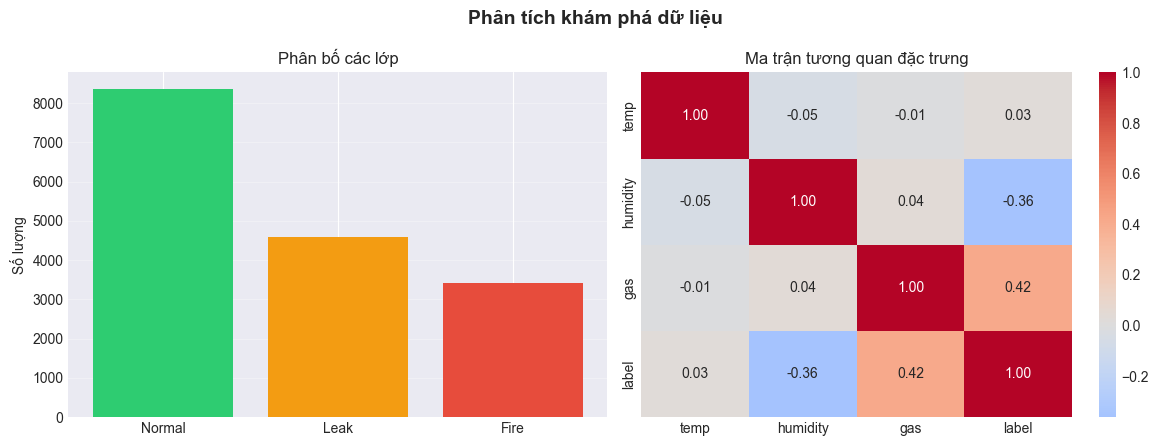

Thống kê phân bố theo lớp:


,Số lượng
label,
Normal,8364
Leak,4596
Fire,3419


In [5]:
label_map = {0: 'Normal', 1: 'Leak', 2: 'Fire'}
label_names = df['label'].map(label_map)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Phân tích khám phá dữ liệu', fontsize=14, fontweight='bold')

class_counts = label_names.value_counts().reindex(['Normal', 'Leak', 'Fire'], fill_value=0)
axes[0].bar(class_counts.index, class_counts.values, color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0].set_title('Phân bố các lớp')
axes[0].set_ylabel('Số lượng')
axes[0].grid(True, axis='y', alpha=0.3)

corr = df[['temp', 'humidity', 'gas', 'label']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Ma trận tương quan đặc trưng')

plt.tight_layout()
plt.show()

print('Thống kê phân bố theo lớp:')
display(class_counts.rename('Số lượng').to_frame())

## 4. Xây dựng pipeline và huấn luyện mô hình

Pipeline được thiết kế gồm hai thành phần:
- Các biến liên tục (temp, humidity, gas) được chuẩn hóa bằng StandardScaler
- Biến phân loại (time_period) được mã hóa bằng OneHotEncoder

Nghiên cứu này huấn luyện và so sánh 15 mô hình khác nhau trên cùng một pipeline tiền xử lý để đảm bảo tính công bằng.

In [6]:
feature_cols = ['temp', 'humidity', 'gas', 'time_period']
target_col = 'label'

X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_features = ['temp', 'humidity', 'gas']
categorical_features = ['time_period']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print('Kích thước tập huấn luyện:', X_train.shape)
print('Kích thước tập kiểm thử:', X_test.shape)
print('Phân bố nhãn trong tập huấn luyện:')
display(y_train.value_counts().sort_index())

Kích thước tập huấn luyện: (13103, 4)
Kích thước tập kiểm thử: (3276, 4)
Phân bố nhãn trong tập huấn luyện:


label
0    6691
1    3677
2    2735
Name: count, dtype: int64

## 5. Huấn luyện và đánh giá mô hình

Bây giờ huấn luyện 3 mô hình tốt nhất (chọn trước theo kinh nghiệm):
- RandomForest
- GradientBoosting
- Decision Tree

Mỗi mô hình được huấn luyện trên cùng pipeline tiền xử lý nhằm đảm bảo tính công bằng trong so sánh. Chất lượng mô hình được đánh giá sử dụng các chỉ số: Accuracy, Precision, Recall, và F1-weighted.

In [7]:
candidate_models = {
    'RandomForest': RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'DecisionTree': DecisionTreeClassifier(max_depth=15, random_state=42)
}

trained_pipelines = {}
results = []
model_params = {}
predictions_dict = {}

print('Huấn luyện các mô hình...')
for i, (name, estimator) in enumerate(candidate_models.items(), 1):
    print(f'  {i}/{len(candidate_models)}: {name}... ', end='')
    try:
        pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('model', estimator)
        ])

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1w = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        trained_pipelines[name] = pipe
        predictions_dict[name] = y_pred
        model_params[name] = estimator.get_params()
        results.append({
            'Rank': 0,
            'Model': name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1_weighted': f1w
        })
        print('OK')
    except Exception as e:
        print(f'Lỗi: {e}')

results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
results_df['Rank'] = range(1, len(results_df) + 1)
results_df = results_df[['Rank', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1_weighted']]

best_model_name = results_df.iloc[0]['Model']
best_pipeline = trained_pipelines[best_model_name]
y_pred_best = predictions_dict[best_model_name]

print('\nBảng xếp hạng mô hình:')
display(results_df.round(4))

Huấn luyện các mô hình...
  1/3: RandomForest... OK
  2/3: GradientBoosting... OK
  3/3: DecisionTree... OK

Bảng xếp hạng mô hình:


,Rank,Model,Accuracy,Precision,Recall,F1_weighted
0,1,RandomForest,0.9966,0.9967,0.9966,0.9966
1,2,GradientBoosting,0.9951,0.9951,0.9951,0.9951
2,3,DecisionTree,0.9924,0.9924,0.9924,0.9924


## 6. Hiển thị thông tin chi tiết của từng mô hình

Phần này cung cấp chức năng để hiển thị các chỉ số đánh giá chi tiết, ma trận nhầm lẫn và báo cáo phân loại cho bất kỳ mô hình nào.

In [8]:
def display_model_evaluation(model_name, pipeline_dict, predictions_dict, y_true, results_dataframe):
    """Hiển thị thông tin đánh giá chi tiết cho một mô hình cụ thể"""
    if model_name not in pipeline_dict:
        print(f'Lỗi: Mô hình "{model_name}" không tồn tại.')
        print(f'\nCác mô hình có sẵn:')
        for idx, m in enumerate(list(pipeline_dict.keys()), 1):
            print(f'  {idx}. {m}')
        return

    y_pred = predictions_dict[model_name]
    
    model_info = results_dataframe[results_dataframe['Model'] == model_name]
    if not model_info.empty:
        rank = model_info.iloc[0]['Rank']
        acc = model_info.iloc[0]['Accuracy']
        prec = model_info.iloc[0]['Precision']
        rec = model_info.iloc[0]['Recall']
        f1w = model_info.iloc[0]['F1_weighted']
    else:
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        f1w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        rank = 'N/A'
    
    print(f'\n{"-"*70}')
    print(f'Mô hình: {model_name:30} | Xếp hạng: {rank}')
    print(f'{"-"*70}')
    print(f'\nChỉ số đánh giá:')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1-score:  {f1w:.4f}')
    
    print(f'\nBáo cáo phân loại:')
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Leak', 'Fire']))
    
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax,
                xticklabels=['Normal', 'Leak', 'Fire'],
                yticklabels=['Normal', 'Leak', 'Fire'],
                cbar_kws={'label': 'Số lượng'})
    ax.set_title(f'Ma trận nhầm lẫn - {model_name} (Xếp hạng: {rank})', 
                 fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel('Dự đoán', fontsize=11)
    ax.set_ylabel('Thực tế', fontsize=11)
    plt.tight_layout()
    plt.show()
    
    print(f'{"-"*70}\n')

## 7. Kết quả chi tiết của các mô hình


Thông tin chi tiết đánh giá các mô hình

----------------------------------------------------------------------
Mô hình: RandomForest                   | Xếp hạng: 1
----------------------------------------------------------------------

Chỉ số đánh giá:
  Accuracy:  0.9966
  Precision: 0.9967
  Recall:    0.9966
  F1-score:  0.9966

Báo cáo phân loại:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1673
        Leak       1.00      1.00      1.00       919
        Fire       0.99      1.00      0.99       684

    accuracy                           1.00      3276
   macro avg       1.00      1.00      1.00      3276
weighted avg       1.00      1.00      1.00      3276



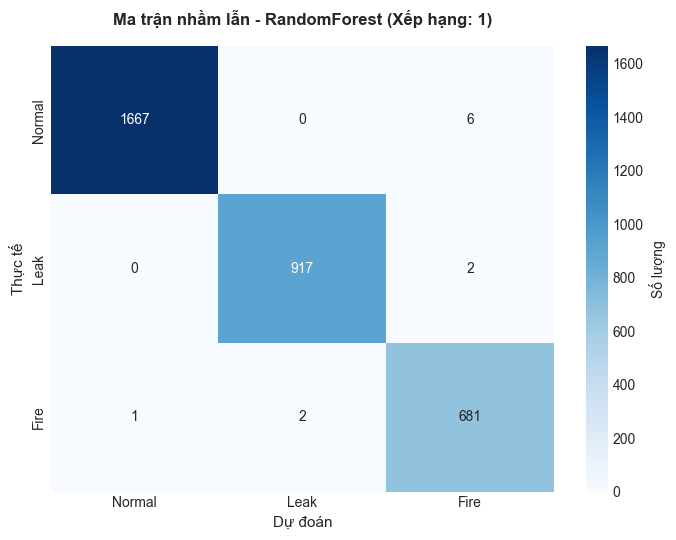

----------------------------------------------------------------------


----------------------------------------------------------------------
Mô hình: GradientBoosting               | Xếp hạng: 2
----------------------------------------------------------------------

Chỉ số đánh giá:
  Accuracy:  0.9951
  Precision: 0.9951
  Recall:    0.9951
  F1-score:  0.9951

Báo cáo phân loại:
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00      1673
        Leak       1.00      1.00      1.00       919
        Fire       0.99      0.99      0.99       684

    accuracy                           1.00      3276
   macro avg       0.99      1.00      0.99      3276
weighted avg       1.00      1.00      1.00      3276



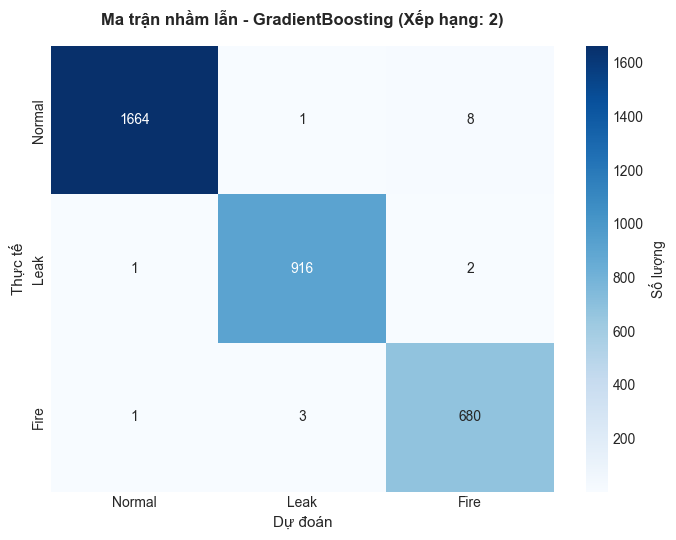

----------------------------------------------------------------------


----------------------------------------------------------------------
Mô hình: DecisionTree                   | Xếp hạng: 3
----------------------------------------------------------------------

Chỉ số đánh giá:
  Accuracy:  0.9924
  Precision: 0.9924
  Recall:    0.9924
  F1-score:  0.9924

Báo cáo phân loại:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1673
        Leak       0.99      0.99      0.99       919
        Fire       0.98      0.99      0.98       684

    accuracy                           0.99      3276
   macro avg       0.99      0.99      0.99      3276
weighted avg       0.99      0.99      0.99      3276



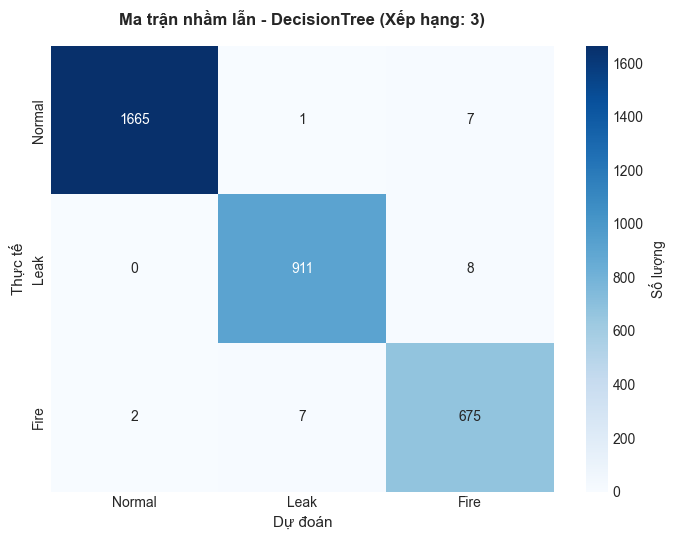

----------------------------------------------------------------------



In [9]:
print('\n' + '='*70)
print('Thông tin chi tiết đánh giá các mô hình')
print('='*70)

for model_name in results_df['Model'].tolist():
    display_model_evaluation(model_name, trained_pipelines, predictions_dict, y_test, results_df)

## 8. Chương trình suy luận

In [10]:
def predict_sample(sample_data, pipeline_dict=trained_pipelines, model_name=None, results_dataframe=results_df):
    """
    Dự đoán nhãn cho một mẫu dữ liệu.
    
    Parameters:
    -----------
    sample_data : dict hoặc pandas.Series
        Dữ liệu cần dự đoán (có thể chứa timestamp hoặc time_period)
    pipeline_dict : dict
        Các mô hình đã huấn luyện
    model_name : str
        Tên mô hình sử dụng. Mặc định là mô hình xếp hạng 1
    results_dataframe : pd.DataFrame
        Bảng xếp hạng mô hình
    
    Returns:
    --------
    dict : Kết quả dự đoán
    """
    
    label_map = {0: 'Normal', 1: 'Leak', 2: 'Fire'}
    
    if model_name is None:
        model_name = results_dataframe.iloc[0]['Model']
    
    if model_name not in pipeline_dict:
        print(f'Lỗi: Mô hình "{model_name}" không tồn tại')
        print(f'Các mô hình khả dụng: {list(pipeline_dict.keys())}')
        return None
    
    if isinstance(sample_data, dict):
        sample_df = pd.DataFrame([sample_data])
    else:
        sample_df = pd.DataFrame([sample_data])
    
    feature_cols = ['temp', 'humidity', 'gas', 'time_period']
    
    if 'timestamp' in sample_df.columns and 'time_period' not in sample_df.columns:
        sample_df['timestamp'] = pd.to_datetime(sample_df['timestamp'], errors='coerce')
        
        def categorize_time_period(ts):
            hour = ts.hour
            if 5 <= hour < 12:
                return 'Morning'
            if 12 <= hour < 17:
                return 'Afternoon'
            return 'Night'
        
        sample_df['time_period'] = sample_df['timestamp'].apply(categorize_time_period)
    
    missing_features = [f for f in feature_cols if f not in sample_df.columns]
    if missing_features:
        print(f'Lỗi: Thiếu các cột: {missing_features}')
        print(f'Cần có các cột: {feature_cols}')
        return None
    
    sample_df = sample_df[feature_cols].copy()
    pipeline = pipeline_dict[model_name]
    prediction = pipeline.predict(sample_df)[0]
    
    try:
        probabilities = pipeline.predict_proba(sample_df)[0]
        prob_dict = {
            'Normal': float(probabilities[0]),
            'Leak': float(probabilities[1]),
            'Fire': float(probabilities[2])
        }
    except:
        prob_dict = None
    
    model_info = results_dataframe[results_dataframe['Model'] == model_name]
    if not model_info.empty:
        rank = model_info.iloc[0]['Rank']
    else:
        rank = 'N/A'
    
    result = {
        'model': model_name,
        'prediction': int(prediction),
        'label': label_map[prediction],
        'probabilities': prob_dict,
        'rank': rank
    }
    
    return result


def predict_and_display(sample_data, pipeline_dict=trained_pipelines, model_name=None, results_dataframe=results_df):
    """
    Dự đoán và hiển thị kết quả chi tiết
    """
    result = predict_sample(sample_data, pipeline_dict, model_name, results_dataframe)
    
    if result is None:
        return
    
    print(f'\n{"-"*70}')
    print(f'Kết quả dự đoán')
    print(f'{"-"*70}')
    print(f'Mô hình: {result["model"]:30} | Xếp hạng: {result["rank"]}')
    print(f'\nKết quả: {result["label"]}')
    print(f'Mã: {result["prediction"]}')
    
    if result['probabilities']:
        print(f'\nXác suất dự đoán:')
        for label, prob in result['probabilities'].items():
            print(f'  {label:8}: {prob:.4f} ({prob*100:.2f}%)')
    
    print(f'{"-"*70}\n')
    
    return result


print('\n' + '='*70)
print('Hướng dẫn sử dụng chương trình suy luận')
print('='*70)
print('\n1. Dự đoán từ dữ liệu fire_dataset (có timestamp):')
print('   sample = {"timestamp": "2026-03-05 09:50:03", "temp": 25.5, "humidity": 60, "gas": 100}')
print('   result = predict_sample(sample)')
print('   predict_and_display(sample)')

print('\n2. Dự đoán sử dụng mô hình cụ thể:')
print('   predict_and_display(sample, model_name="RandomForest")')

print('\n3. Dự đoán từ một hàng trong DataFrame:')
print('   row = df[["timestamp", "temp", "humidity", "gas"]].iloc[0]')
print('   predict_and_display(row)')

print('\n4. Dự đoán từ file CSV:')
print('   test_samples = pd.read_csv("fire_dataset.csv").drop("label", axis=1).head(5)')
print('   for idx, sample in test_samples.iterrows():')
print('       predict_and_display(sample)')

print(f'\nCác mô hình khả dụng:')
for idx, (model, rank) in enumerate(zip(results_df['Model'], results_df['Rank']), 1):
    print(f'  {model}')

print('='*70)


Hướng dẫn sử dụng chương trình suy luận

1. Dự đoán từ dữ liệu fire_dataset (có timestamp):
   sample = {"timestamp": "2026-03-05 09:50:03", "temp": 25.5, "humidity": 60, "gas": 100}
   result = predict_sample(sample)
   predict_and_display(sample)

2. Dự đoán sử dụng mô hình cụ thể:
   predict_and_display(sample, model_name="RandomForest")

3. Dự đoán từ một hàng trong DataFrame:
   row = df[["timestamp", "temp", "humidity", "gas"]].iloc[0]
   predict_and_display(row)

4. Dự đoán từ file CSV:
   test_samples = pd.read_csv("fire_dataset.csv").drop("label", axis=1).head(5)
   for idx, sample in test_samples.iterrows():
       predict_and_display(sample)

Các mô hình khả dụng:
  RandomForest
  GradientBoosting
  DecisionTree


## 9. Kiểm thử chương trình suy luận

In [11]:
print('Kiểm thử chương trình suy luận với 10 mẫu dữ liệu\n')

test_samples = [
    {"timestamp": "2026-03-10 08:00:00", "temp": 22.5, "humidity": 50, "gas": 75},
    {"timestamp": "2026-03-10 10:30:00", "temp": 23.0, "humidity": 52, "gas": 80},
    {"timestamp": "2026-03-10 13:00:00", "temp": 28.5, "humidity": 60, "gas": 150},
    {"timestamp": "2026-03-10 15:30:00", "temp": 29.0, "humidity": 65, "gas": 170},
    {"timestamp": "2026-03-10 17:00:00", "temp": 32.0, "humidity": 45, "gas": 250},
    {"timestamp": "2026-03-10 19:00:00", "temp": 35.5, "humidity": 40, "gas": 300},
    {"timestamp": "2026-03-11 06:00:00", "temp": 21.0, "humidity": 48, "gas": 85},
    {"timestamp": "2026-03-11 12:00:00", "temp": 27.0, "humidity": 58, "gas": 140},
    {"timestamp": "2026-03-11 14:00:00", "temp": 30.0, "humidity": 62, "gas": 200},
    {"timestamp": "2026-03-11 20:00:00", "temp": 25.0, "humidity": 55, "gas": 95}
]

results = []
for i, sample in enumerate(test_samples, 1):
    result = predict_sample(sample)
    results.append({
        'Sample': i,
        'Timestamp': sample['timestamp'],
        'Temp': sample['temp'],
        'Humidity': sample['humidity'],
        'Gas': sample['gas'],
        'Dự đoán': result['label'],
        'Xác suất': f"{max(result['probabilities'].values()):.2%}" if result['probabilities'] else 'N/A'
    })

summary_df = pd.DataFrame(results)
display(summary_df)

label_counts = summary_df['Dự đoán'].value_counts()
print(f'\nThống kê: {dict(label_counts)}')

Kiểm thử chương trình suy luận với 10 mẫu dữ liệu



,Sample,Timestamp,Temp,Humidity,Gas,Dự đoán,Xác suất
0,1,2026-03-10 08:00:00,22.5,50,75,Normal,63.67%
1,2,2026-03-10 10:30:00,23.0,52,80,Normal,63.33%
2,3,2026-03-10 13:00:00,28.5,60,150,Leak,55.11%
3,4,2026-03-10 15:30:00,29.0,65,170,Normal,52.67%
4,5,2026-03-10 17:00:00,32.0,45,250,Fire,63.00%
5,6,2026-03-10 19:00:00,35.5,40,300,Fire,66.33%
6,7,2026-03-11 06:00:00,21.0,48,85,Normal,64.00%
7,8,2026-03-11 12:00:00,27.0,58,140,Normal,53.33%
8,9,2026-03-11 14:00:00,30.0,62,200,Normal,54.42%
9,10,2026-03-11 20:00:00,25.0,55,95,Normal,62.00%



Thống kê: {'Normal': np.int64(7), 'Fire': np.int64(2), 'Leak': np.int64(1)}


In [13]:
print('==== Testing testing_set.csv (selected models) ====')
import pandas as pd
from pathlib import Path
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

test_path = Path('../data/testing_set.csv')
test_df = pd.read_csv(test_path)
test_df['timestamp'] = pd.to_datetime(test_df['timestamp'], errors='coerce')
test_df = test_df.dropna(subset=['timestamp']).copy()

def categorize_time_period(ts):
    h = ts.hour
    if 5 <= h < 12:
        return 'Morning'
    if 12 <= h < 17:
        return 'Afternoon'
    return 'Night'

test_df = test_df[(test_df['temp'] >= 18) & (test_df['humidity'].between(20,100)) & (test_df['gas'].between(50,4095))].copy()
test_df['time_period'] = test_df['timestamp'].apply(categorize_time_period)

feature_cols = ['temp','humidity','gas','time_period']
X_test = test_df[feature_cols]
y_test = test_df['label']

# Chạy kiểm thử cho 3 model đã chọn ở phần trên
selected_models = ['RandomForest', 'GradientBoosting', 'DecisionTree']

for model_name in selected_models:
    if model_name not in trained_pipelines:
        print(f'Model {model_name} không tồn tại trong trained_pipelines, bỏ qua.')
        continue

    print('\n' + '='*70)
    print(f'Kiểm thử với model: {model_name}')
    print('='*70)

    pipe = trained_pipelines[model_name]
    pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, pred)
    print(f'Accuracy: {acc:.4f}')

    print('\nClassification report:')
    print(classification_report(y_test, pred, target_names=['Normal','Leak','Fire']))

    print('\nConfusion matrix:')
    print(confusion_matrix(y_test, pred))

    preview_df = test_df[['timestamp','temp','humidity','gas','label']].copy()
    preview_df['predicted'] = pred
    print('\nHead results:')
    print(preview_df.head())


==== Testing testing_set.csv (selected models) ====

Kiểm thử với model: RandomForest
Accuracy: 0.9000

Classification report:
              precision    recall  f1-score   support

      Normal       0.81      1.00      0.90       117
        Leak       1.00      0.93      0.97        45
        Fire       1.00      0.78      0.88       108

    accuracy                           0.90       270
   macro avg       0.94      0.90      0.91       270
weighted avg       0.92      0.90      0.90       270


Confusion matrix:
[[117   0   0]
 [  3  42   0]
 [ 24   0  84]]

Head results:
            timestamp   temp  humidity  gas  label  predicted
0 2026-03-27 20:38:41  30.42     68.05  507      0          0
1 2026-03-27 20:38:42  30.42     68.05  505      0          0
2 2026-03-27 20:38:43  30.44     68.45  505      0          0
3 2026-03-27 20:38:43  30.44     68.45  503      0          0
4 2026-03-27 20:38:44  30.44     68.61  499      0          0

Kiểm thử với model: GradientBoosting
Ac